# LC Wrapper E2E Test - Interactive Input on JupyterLab

- Test that input() function works properly
- Test that getpass works properly
- Verify stdin handling in LC Wrapper kernel

In [ ]:
jupyterlab_url = "http://localhost:8888/lab?token=test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 10000
default_delay = 200
browser_type = "chromium"
jupyter_work_dir = '../artifacts/jupyter-work'

In [22]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmplh590gm0'

In [23]:
import re
import asyncio
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

import scripts.lc_wrapper as lc_wrapper
importlib.reload(lc_wrapper)

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, delay=default_delay, browser_type=browser_type)

('20251201-065600',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpfav09x5b')

## Open JupyterLab and wait for it to load

Start epoch: 1764539760.822026 seconds


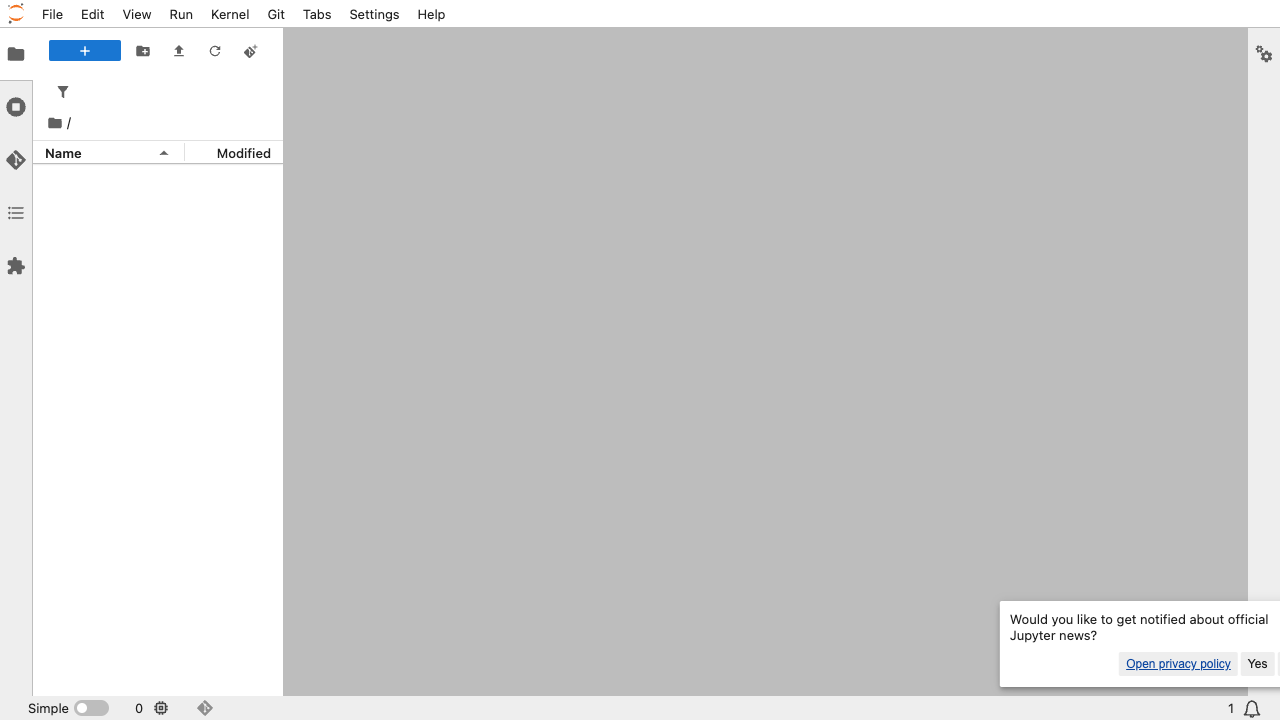

In [24]:
lab_page = None

async def _step(page):
    await page.goto(jupyterlab_url)

    # Wait for JupyterLab to load
    await expect(page.locator('#jp-main-dock-panel')).to_be_visible(timeout=transition_timeout)

    # Wait for file browser to be visible
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

    global lab_page
    lab_page = page

await run_pw(_step)

## Remove existing test notebook if it exists

Start epoch: 1764539762.387488 seconds
Test notebook 'TestInteractiveNotebook.ipynb' does not exist. Creating a new one.


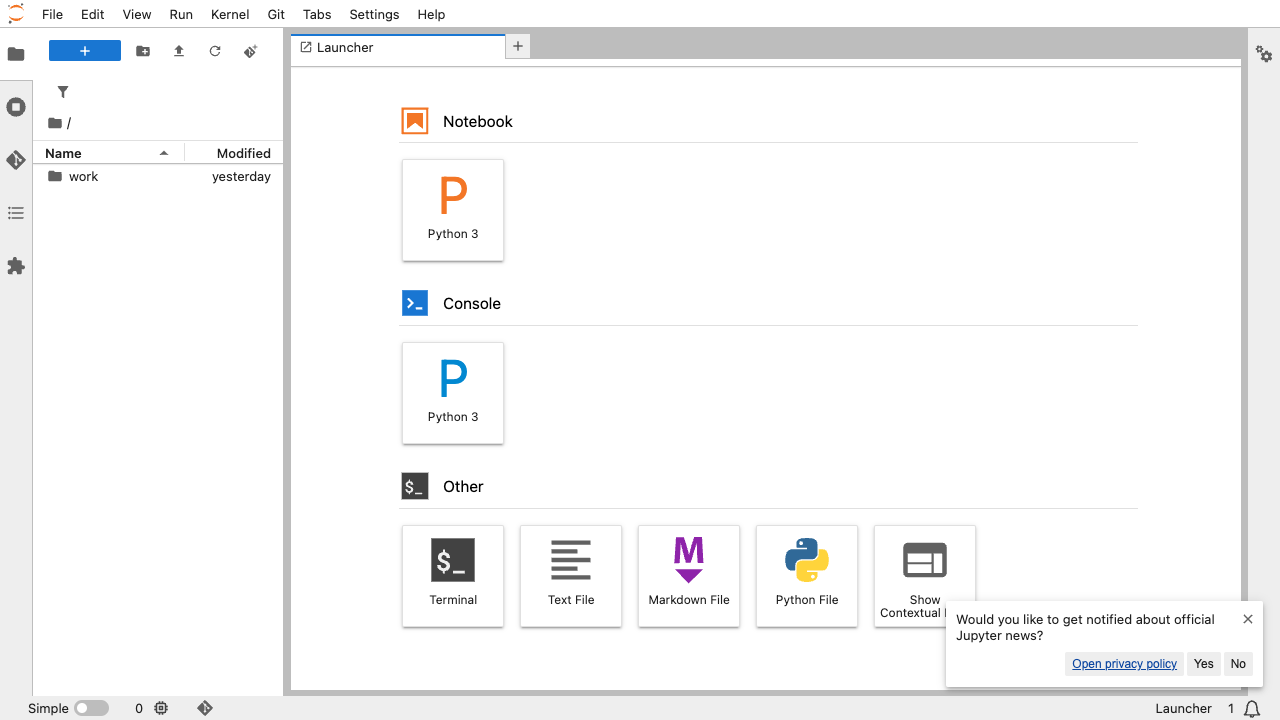

In [25]:
import scripts.lc_wrapper
importlib.reload(scripts.lc_wrapper)

test_filename = 'TestInteractiveNotebook.ipynb'

async def _step(page):
    await asyncio.sleep(3)  # Wait for file browser to stabilize
    test_filename_locator = lc_wrapper.get_file_browser_item_locator(page, test_filename)
    
    if not await test_filename_locator.is_visible():
        print(f"Test notebook '{test_filename}' does not exist. Creating a new one.")
        return
    
    await test_filename_locator.click(button='right')
    await page.locator('//*[@data-command="filebrowser:delete"]').click()

    await page.locator('//*[contains(@class, "jp-Dialog-buttonLabel") and text()="Delete"]').click()

    await expect(test_filename_locator).not_to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## Create a new notebook with LC_wrapper kernel

Start epoch: 1764539765.685654 seconds
Created notebook panel: id-133d6389-0a2d-499a-adb3-009a4fa15c43


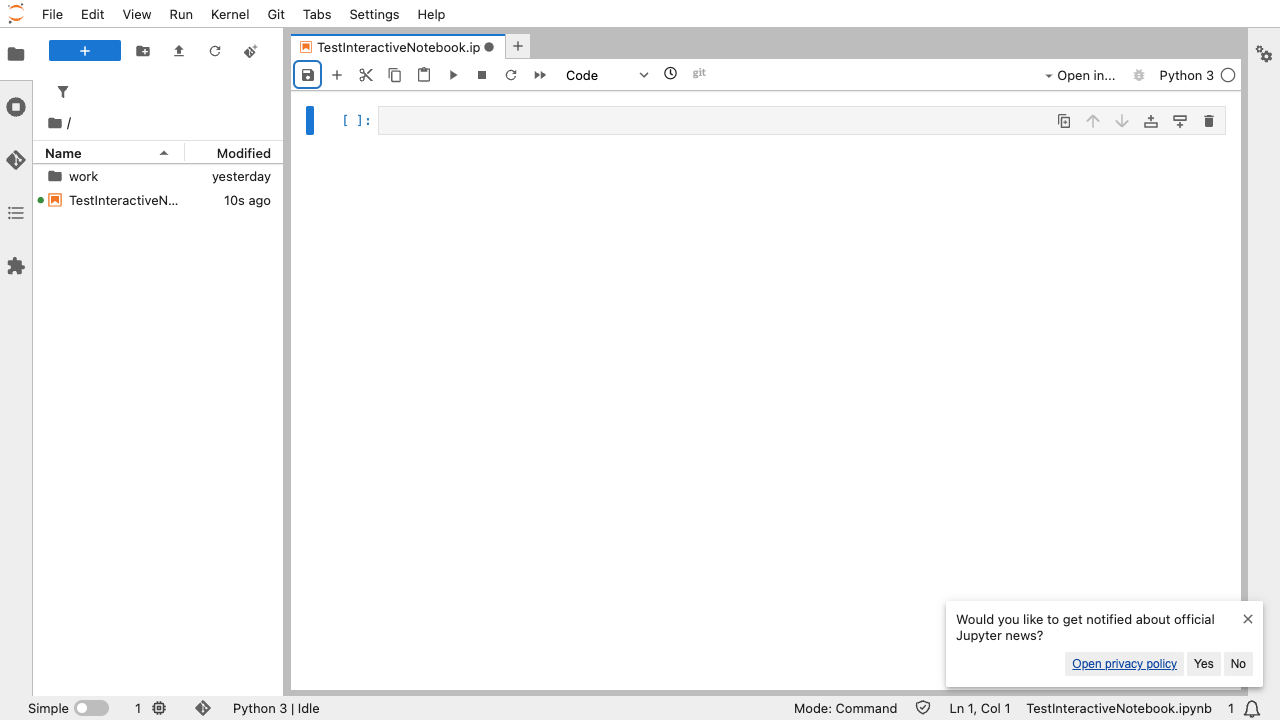

In [26]:
import scripts.lc_wrapper as lc_wrapper
importlib.reload(lc_wrapper)

created_panel_id = None

async def _step(page):
    await lc_wrapper.ensure_launcher_tab_opened(page)

    old_panel_ids = await lc_wrapper.get_notebook_panel_ids(page)

    # Click on "Python 3" notebook to create a new notebook
    await page.locator('//*[contains(@class, "jp-Launcher-sectionTitle") and text()="Notebook"]/../..').locator('//div[@title="Python 3" and @class="jp-LauncherCard-label"]').click()
    
    # Wait for notebook to open
    await expect(page.locator('//*[contains(@class, "jp-mod-current")]//*[contains(@class, "lm-TabBar-tabLabel") and text() = "Untitled.ipynb"]')).to_be_visible(timeout=transition_timeout)
    
    new_panel_ids = await lc_wrapper.get_notebook_panel_ids(page)
    created_panel_ids = new_panel_ids - old_panel_ids
    assert len(created_panel_ids) == 1, f"Expected one new notebook panel to be created, old_panel_ids: {old_panel_ids}, new_panel_ids: {new_panel_ids}"
    
    global created_panel_id
    created_panel_id = created_panel_ids.pop()
    
    print(f"Created notebook panel: {created_panel_id}")
    
    await page.locator('//*[@data-command="docmanager:save"]').click()

    await page.locator('//*[contains(@class, "jp-Dialog-header") and text()="Rename file"]/..//input[@placeholder="File name"]').fill(test_filename)

    await page.locator('//*[contains(@class, "jp-Dialog-buttonLabel") and text()="Rename and Save"]').click()

    await expect(lc_wrapper.get_file_browser_item_locator(page, test_filename)).to_be_visible(timeout=transition_timeout * 3)

await run_pw(_step)

## Test input() function

Start epoch: 1764539777.229326 seconds
Stdin input field appeared
Prompt displayed: Enter your name: 
input() function test passed!


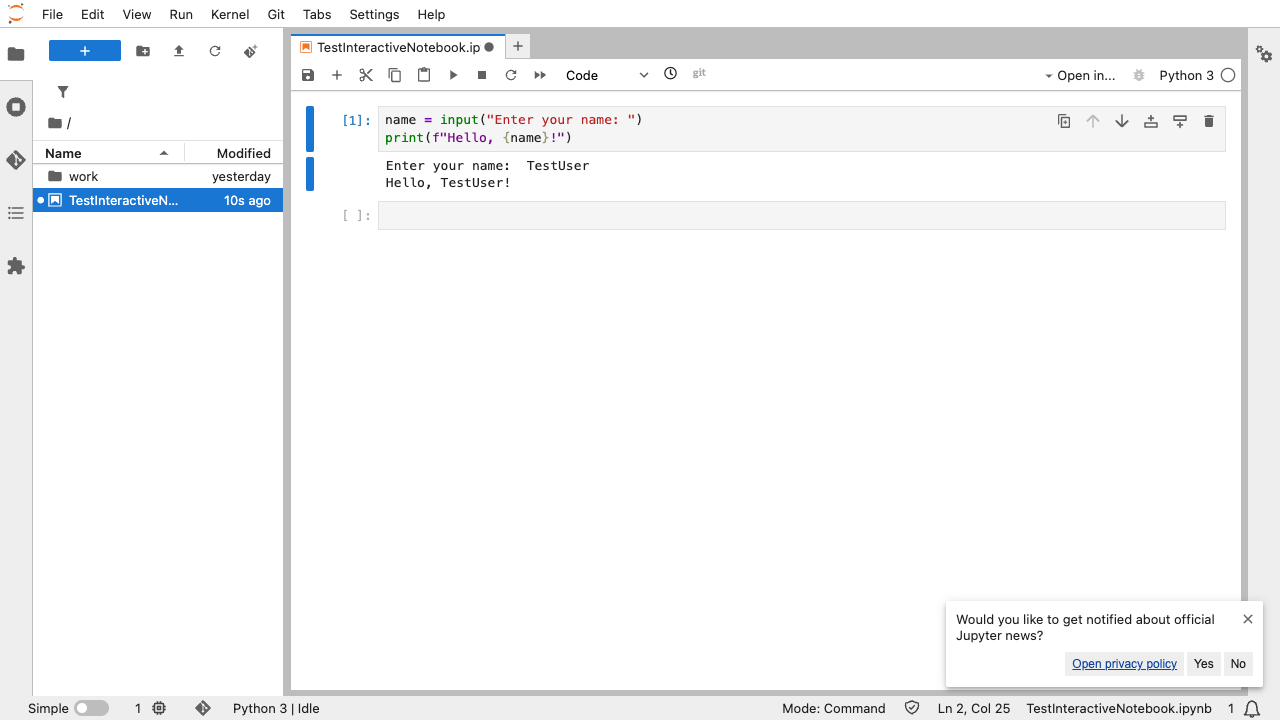

In [27]:
async def _step(page):
    panel = page.locator(f'#{created_panel_id}')
    cell = panel.locator('.jp-Cell-inputArea .cm-content').first
    
    # Enter code that uses input()
    await cell.click()
    await cell.type('name = input("Enter your name: ")', delay=50)
    await page.keyboard.press('Enter')
    await cell.type('print(f"Hello, {name}!")', delay=50)
    
    # Execute with Shift+Enter
    await page.keyboard.press('Shift+Enter')
    
    # Wait for stdin input field to appear
    stdin_input = panel.locator('.jp-Stdin-input')
    await expect(stdin_input).to_be_visible(timeout=transition_timeout)
    print("Stdin input field appeared")
    
    # Verify prompt is displayed
    prompt = panel.locator('.jp-Stdin-prompt')
    prompt_text = await prompt.inner_text()
    assert 'Enter your name:' in prompt_text, f"Expected prompt 'Enter your name:', got '{prompt_text}'"
    print(f"Prompt displayed: {prompt_text}")
    
    # Type input value
    await stdin_input.fill('TestUser')
    await stdin_input.press('Enter')
    
    # Wait for execution to complete
    #await asyncio.sleep(2)
    
    # Verify output
    first_cell = panel.locator('.jp-Cell').nth(0)
    output = first_cell.locator('.jp-OutputArea-output')
    await expect(output.filter(has_text="Hello, TestUser!")).to_be_visible(timeout=transition_timeout)
    
    print("input() function test passed!")

await run_pw(_step)

## Test getpass (password input)

Start epoch: 1764539780.758452 seconds
Password input field appeared with correct type
getpass test passed!


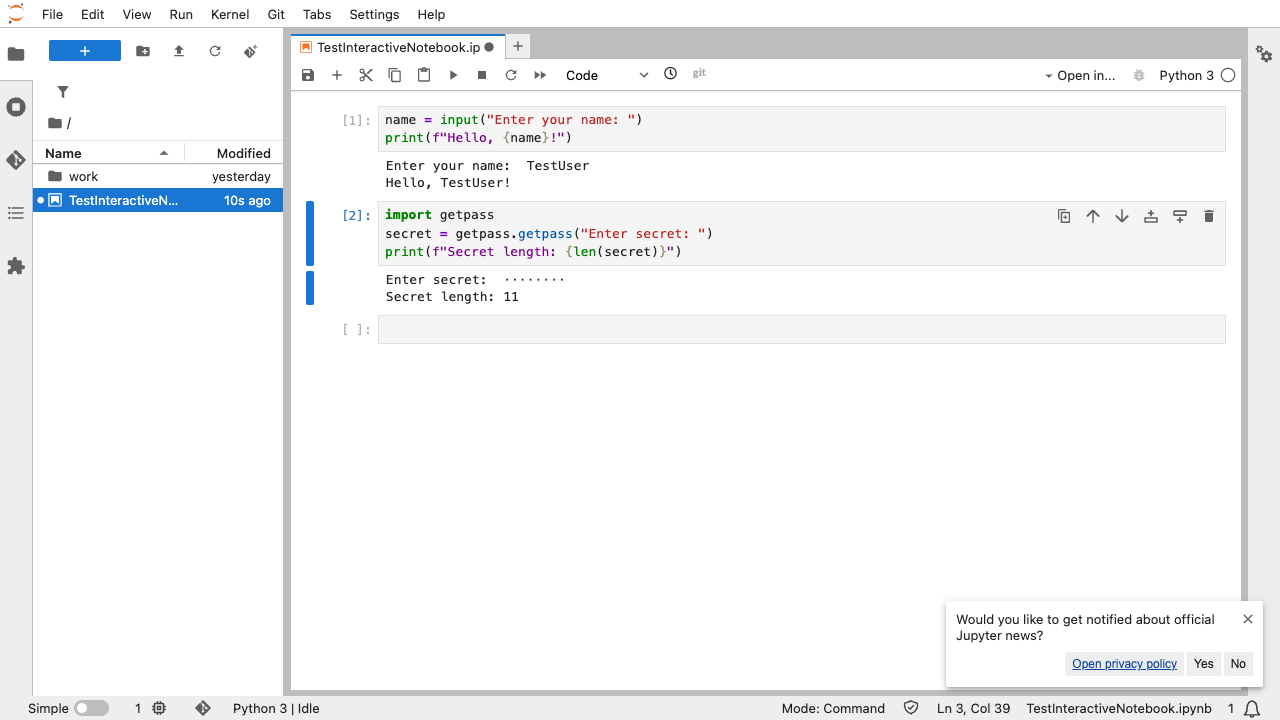

In [28]:
async def _step(page):
    panel = page.locator(f'#{created_panel_id}')
    
    # Get the current cell (should be new cell after previous execution)
    await asyncio.sleep(0.5)
    cells = panel.locator('.jp-Cell')
    cell_count = await cells.count()
    cell = cells.nth(cell_count - 1)
    editor = cell.locator('.cm-content')
    
    # Enter code that uses getpass
    await editor.click()
    await editor.type('import getpass', delay=50)
    await page.keyboard.press('Enter')
    await editor.type('secret = getpass.getpass("Enter secret: ")', delay=50)
    await page.keyboard.press('Enter')
    await editor.type('print(f"Secret length: {len(secret)}")', delay=50)
    
    # Execute with Shift+Enter
    await page.keyboard.press('Shift+Enter')
    
    # Wait for stdin input field to appear (password type)
    stdin_input = panel.locator('.jp-Stdin-input')
    await expect(stdin_input).to_be_visible(timeout=transition_timeout)
    
    # Verify it's a password field
    input_type = await stdin_input.get_attribute('type')
    assert input_type == 'password', f"Expected password input type, got '{input_type}'"
    print("Password input field appeared with correct type")
    
    # Type password
    await stdin_input.fill('mysecret123')
    await stdin_input.press('Enter')
    
    # Wait for execution to complete
    #await asyncio.sleep(2)
    
    # Verify output shows length (not the actual secret)
    current_cell = cells.nth(cell_count - 1)
    output = current_cell.locator('.jp-OutputArea-output')
    await expect(output.filter(has_text="Secret length: 11")).to_be_visible(timeout=transition_timeout)
    
    print("getpass test passed!")

await run_pw(_step)

## Clean up

In [ ]:
await finish_pw_context()

In [30]:
!rm -fr {work_dir}